# 07-1. Tavily 검색 노드 만들기

이 실습은 LangGraph에서 외부 검색 도구를 하나의 노드로 연결하는 가장 단순한 예제이다.

## 학습 목표

1. Tavily 검색 도구를 LangGraph 노드로 만든다.
2. `State`에 검색어와 검색 결과를 저장한다.
3. `START → 검색 → END` 구조의 가장 단순한 그래프를 구성한다.
4. `invoke()`와 `stream()`으로 실행 결과를 확인한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
END
```

이 단계에서는 LLM을 사용하지 않는다. 먼저 외부 검색 API가 LangGraph 노드 안에서 어떻게 실행되는지만 확인한다.


## 0. 설치 패키지

이 실습은 LangGraph, OpenAI 모델, Tavily 검색 도구를 사용한다.  
처음 실행하는 환경에서는 아래 명령으로 필요한 패키지를 설치한다.

```bash
uv add langgraph langchain-openai langchain-tavily langchain-core python-dotenv grandalf
```

`.env` 파일에는 다음 값을 설정한다.

```text
OPENAI_API_KEY=발급받은_OpenAI_API_Key
TAVILY_API_KEY=발급받은_Tavily_API_Key
```


In [1]:
# 공통 환경 설정
# - .env 파일에서 API Key를 읽는다.
# - API Key가 없으면 실습 초반에 명확한 오류를 발생시킨다.
import os
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../.env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")


환경 변수 로드 완료


In [2]:
# LangGraph 기본 구성 요소와 Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from IPython.display import Image, display

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
# max_results는 검색 결과 개수를 의미한다.
tavily_tool = TavilySearch(max_results=5)

In [3]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


## 1. State 정의

`State`는 그래프 실행 중 유지되는 공유 상태 객체이다.

이 단계에서는 세 가지 정보만 사용한다.

| 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 주제 |
| `search_query` | 실제 Tavily에 전달할 검색어 |
| `search_results` | Tavily 검색 결과 |


In [4]:
class SearchState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 실제 Tavily 검색에 사용할 검색어이다.
    search_query: str

    # Tavily에서 받은 검색 결과 목록이다.
    search_results: list[dict]


## 2. 검색 노드 정의

노드는 State를 입력으로 받고, 변경할 값만 딕셔너리로 반환한다.

이 노드는 다음 작업을 수행한다.

1. `topic` 값을 검색어로 사용한다.
2. Tavily 검색을 실행한다.
3. 검색 결과를 `search_results`에 저장한다.


In [5]:
def search_node(state: SearchState) -> dict:
    """Tavily 검색을 수행하는 노드이다."""

    # topic을 실제 검색어로 사용한다.
    query = state["topic"]
    print(f"검색어: {query}")

    # Tavily 검색 도구를 실행한다.
    raw_result = tavily_tool.invoke({"query": query})

    # Tavily 결과에서 results 리스트만 추출한다.
    results = normalize_tavily_results(raw_result)
    print(f"검색 결과 수: {len(results)}")

    # 노드는 변경할 State 값만 반환한다.
    return {
        "search_query": query,
        "search_results": results,
    }


## 3. 그래프 구성

가장 단순한 그래프는 하나의 노드만 가진다.

```text
START → 검색 → END
```


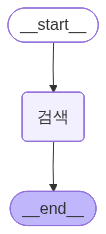

In [6]:
# StateGraph는 SearchState 구조를 기준으로 그래프를 만든다.
builder = StateGraph(SearchState)

# 검색 노드를 그래프에 등록한다.
builder.add_node("검색", search_node)

# START에서 검색 노드로 이동한다.
builder.add_edge(START, "검색")

# 검색 노드가 끝나면 그래프를 종료한다.
builder.add_edge("검색", END)

# compile()을 해야 실행 가능한 그래프가 된다.
app = builder.compile()

show_graph(app)


## 4. 그래프 실행

`invoke()`는 그래프를 처음부터 끝까지 실행하고 최종 State를 반환한다.


In [7]:
result = app.invoke({
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
})

print("최종 검색어:", result["search_query"])
print("검색 결과 수:", len(result["search_results"]))

# 검색 결과 제목만 간단히 확인한다.
for idx, item in enumerate(result["search_results"], start=1):
    print(f"{idx}. {item.get('title', '제목 없음')}")


검색어: 인공지능 최신 동향
검색 결과 수: 5
최종 검색어: 인공지능 최신 동향
검색 결과 수: 5
1. [AI Part.2] AI의 현재와 나아갈 길_AI의 최신 기술 동향 총정리 - 투비통
2. 인공지능 분야 산업·기술 동향 및 이슈
3. 인공지능 최신기술동향 -2025년7월(Claude4, Grok4 ... - YouTube
4. 2025 AI 최신 트렌드를 한눈에 - 국내외 필수 AI 정보 허브 총정리
5. SPRi - 소프트웨어정책연구소 : 연구자료


## 5. stream으로 단계별 실행 확인

`stream_mode="updates"`는 각 노드가 반환한 업데이트 값만 보여준다.  
검색 노드가 어떤 값을 State에 추가하는지 확인할 수 있다.


In [ ]:
for event in app.stream(
    {
        "topic": "2026년 생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
    },
    stream_mode="updates",
):
    # print(event)
    # for update_data in event.values():
    #     print(update_data)
    for update_data in event.values():
        if "search_results" in update_data:
            for i, item in enumerate(update_data["search_results"], start=1):
                print(f"\n[{i}] {item.get('title')}")
                print(item.get("url"))
                print(item.get("content"))


검색어: 2026년 생성형 AI 교육 트렌드 url 오픈 가능한 자료만 추출하기
검색 결과 수: 5

[1] 2026년 3월 셋째 주 AI 트렌드
https://www.carrotglobalblog.com/ai-trends-2026-march-third-week
# 2026년 3월 셋째 주 AI 트렌드. 이번 주 AI 뉴스를 한 줄로 요약하면 이렇습니다. 이제 AI는 답해주는 도구를 넘어서, 기업 전용 모델을 만들고, 코드를 더 많이 쓰고, 스마트폰 앱을 대신 조작하고, 심지어 조직 구조까지 흔들기 시작했습니다. By AX Center  5 min read. 회사 전용 AI 모델 구축 - Forge. 미스트랄은 3월 17일 **Forge**를 공개했습니다. 기업이 자기 회사의 문서, 코드, 운영 데이터, 정책 같은 내부 지식을 바탕으로 모델을 직접 학습하고, 사전학습·후속학습·강화학습까지 이어가며 계속 다듬을 수 있게 하겠다는 겁니다. 젤리피시가 700개 이상 기업, 20만 명 개발자, 2천만 건 이상의 PR을 분석한 자료에 따르면 기업들의 AI 코딩 도구 도입률 중앙값은 63%였고, 64%는 코드의 과반을 AI 도움으로 생성하는 것으로 나타났습니다. 바이브 코딩은 더 이상 일부 얼리어답터의 실험이 아니라, 이미 조직 생산성 경쟁의 한가운데 들어왔다는 점입니다. 이제 중요한 질문은 “AI 코딩을 도입할까?”가 아니라 **“검토, 품질 관리, 책임 분배를 어떻게 설계할까?”**에 가까워졌습니다. 생성형 AI 활용부터 조직 전반의 AI 확산 전략까지, 귀사의 상황에 맞춘 최적의 솔루션을 함께 고민하겠습니다. ##### Posted by AX Center.

[2] 한화인재경영원 Track C. 연구개발/생산품질 교안 | 2026년 3월
https://kgpt.or.kr/wp-content/uploads/2026/03/%ED%95%9C%ED%99%94%EC%9D%B8%EC%9E%AC%EA%B2%BD%EC%98%81%EC%9B%90_%EC%97%B0%EA%B5%AC%

## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 외부 API 호출도 LangGraph 노드 안에서 실행할 수 있다.
2. 노드는 전체 State가 아니라 변경할 값만 반환한다.
3. `START → 검색 → END` 구조는 가장 단순한 LangGraph 파이프라인이다.
4. 다음 단계에서는 검색 결과를 LLM으로 정리하는 노드를 추가한다.


---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=5,
    topic="news",
    search_depth="advanced",
    time_range="month",
)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]

# 2. LangGraph State 정의
from typing_extensions import TypedDict

class SearchState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]

# 3. 검색 노드 정의
def search_node(state: SearchState) -> dict:
    query = state["search_query"] or state["topic"]
    raw_result = tavily_tool.invoke({"query": query})
    results = raw_result["results"]

    return {
        "search_query": query,
        "search_results": results,
    }

# 4. 그래프 구성
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SearchState)
builder.add_node("검색", search_node)
builder.add_edge(START, "검색")
builder.add_edge("검색", END)

app = builder.compile()
```

| 구성 요소 | 역할 |
|---|---|
| `SearchState` | 그래프 실행 중 유지할 상태 구조를 정의한다. |
| `검색` 노드 | Tavily Search API로 최신 뉴스 검색을 수행한다. |
| `search_query` | 실제 검색에 사용한 검색어를 저장한다. |
| `search_results` | Tavily에서 반환한 검색 결과 목록을 저장한다. |
| `START → 검색 → END` | 하나의 검색 노드만 실행하는 가장 단순한 LangGraph 흐름이다. |

이 실습은 LangGraph에서 **외부 API 호출을 하나의 노드로 구성하고, 실행 결과를 State에 저장하는 기본 예제**이다.
